In [12]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

print("Libraries imported successfully.")


Libraries imported successfully.


In [13]:
PROJECT_ROOT = Path.cwd().parent
ENV_FILE = PROJECT_ROOT / ".env"

load_dotenv(ENV_FILE)

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(database_url)

print("Database connection settings loaded.")

Database connection settings loaded.


In [14]:
%pip install psycopg2-binary


Note: you may need to restart the kernel to use updated packages.


In [15]:
query = """
SELECT *
FROM public.currency_rates
ORDER BY target_currency;
"""

currency_df = pd.read_sql(query, engine)

currency_df

,rate_date,base_currency,target_currency,exchange_rate,collection_timestamp,inverse_rate,rate_strength_category,collection_date,collection_hour
0,2026-06-19,EUR,AUD,1.63480,2026-06-21 19:14:49.354547,0.611696,Between 1 and 10,2026-06-21,19
1,2026-06-19,EUR,CAD,1.62280,2026-06-21 19:14:49.354547,0.616219,Between 1 and 10,2026-06-21,19
2,2026-06-19,EUR,CHF,0.92480,2026-06-21 19:14:49.354547,1.081315,Below 1,2026-06-21,19
3,2026-06-19,EUR,GBP,0.86653,2026-06-21 19:14:49.354547,1.154028,Below 1,2026-06-21,19
4,2026-06-19,EUR,INR,108.16750,2026-06-21 19:14:49.354547,0.009245,Above 100,2026-06-21,19
5,2026-06-19,EUR,JPY,184.88000,2026-06-21 19:14:49.354547,0.005409,Above 100,2026-06-21,19
6,2026-06-19,EUR,USD,1.14670,2026-06-21 19:14:49.354547,0.872068,Between 1 and 10,2026-06-21,19


In [16]:
print("Rows:", currency_df.shape[0])
print("Columns:", currency_df.shape[1])

currency_df.info()

Rows: 7
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rate_date               7 non-null      datetime64[ns]
 1   base_currency           7 non-null      object        
 2   target_currency         7 non-null      object        
 3   exchange_rate           7 non-null      float64       
 4   collection_timestamp    7 non-null      datetime64[ns]
 5   inverse_rate            7 non-null      float64       
 6   rate_strength_category  7 non-null      object        
 7   collection_date         7 non-null      object        
 8   collection_hour         7 non-null      int64         
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 636.0+ bytes


In [17]:
currency_df.describe(include="all")

,rate_date,base_currency,target_currency,exchange_rate,collection_timestamp,inverse_rate,rate_strength_category,collection_date,collection_hour
count,7,7,7,7.000000,7,7.000000,7,7,7.0
unique,NaN,1,7,NaN,NaN,NaN,3,1,NaN
top,NaN,EUR,AUD,NaN,NaN,NaN,Between 1 and 10,2026-06-21,NaN
freq,NaN,7,1,NaN,NaN,NaN,3,7,NaN
mean,2026-06-19 00:00:00,NaN,NaN,42.749019,2026-06-21 19:14:49.354546944,0.621426,NaN,NaN,19.0
min,2026-06-19 00:00:00,NaN,NaN,0.866530,2026-06-21 19:14:49.354547,0.005409,NaN,NaN,19.0
25%,2026-06-19 00:00:00,NaN,NaN,1.035750,2026-06-21 19:14:49.354546944,0.310470,NaN,NaN,19.0
50%,2026-06-19 00:00:00,NaN,NaN,1.622800,2026-06-21 19:14:49.354546944,0.616219,NaN,NaN,19.0
75%,2026-06-19 00:00:00,NaN,NaN,54.901150,2026-06-21 19:14:49.354546944,0.976692,NaN,NaN,19.0
max,2026-06-19 00:00:00,NaN,NaN,184.880000,2026-06-21 19:14:49.354547,1.154028,NaN,NaN,19.0


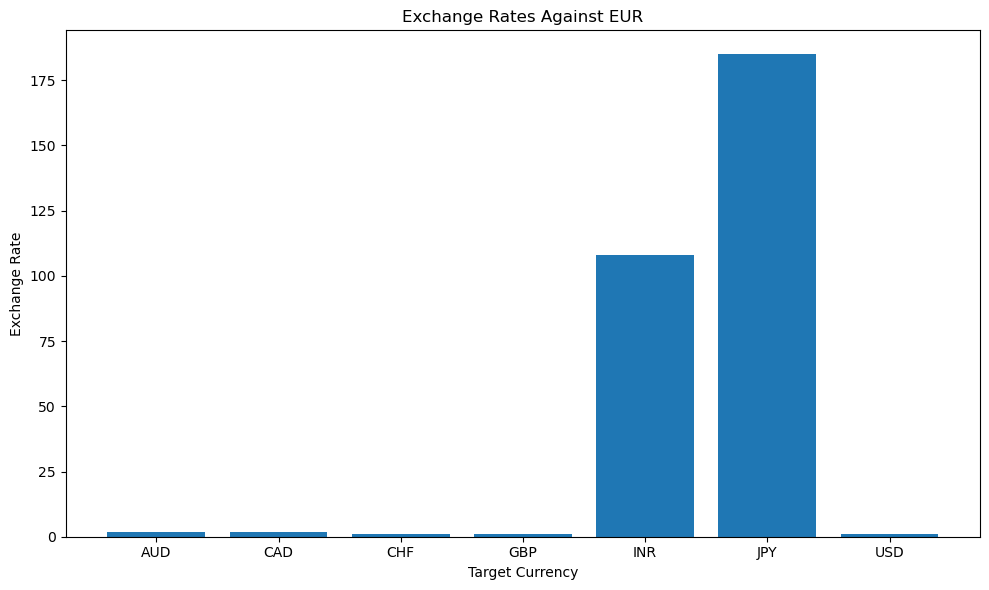

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    currency_df["target_currency"],
    currency_df["exchange_rate"]
)

plt.title("Exchange Rates Against EUR")
plt.xlabel("Target Currency")
plt.ylabel("Exchange Rate")
plt.tight_layout()
plt.show()

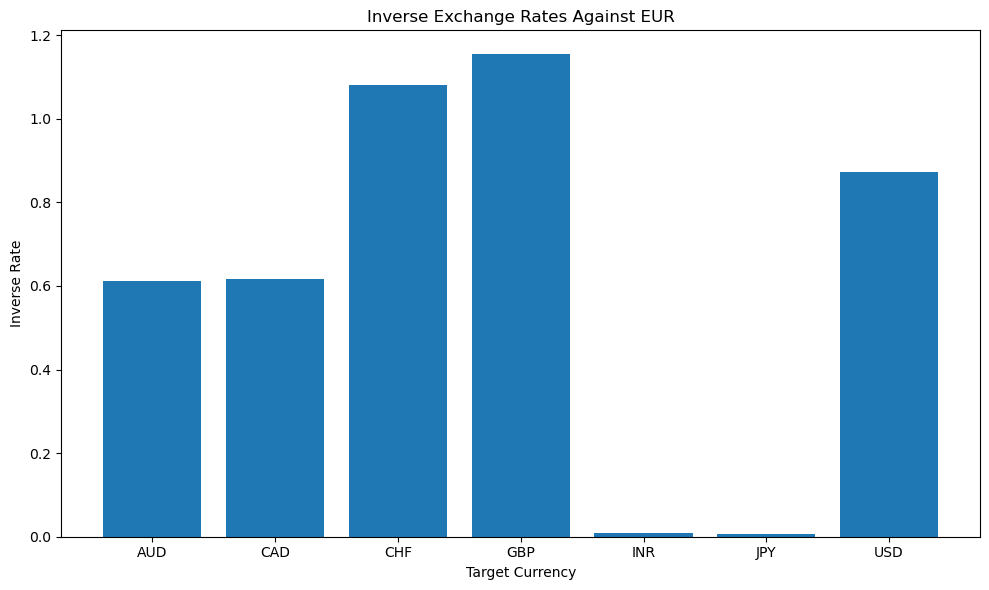

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(
    currency_df["target_currency"],
    currency_df["inverse_rate"]
)

plt.title("Inverse Exchange Rates Against EUR")
plt.xlabel("Target Currency")
plt.ylabel("Inverse Rate")
plt.tight_layout()
plt.show()

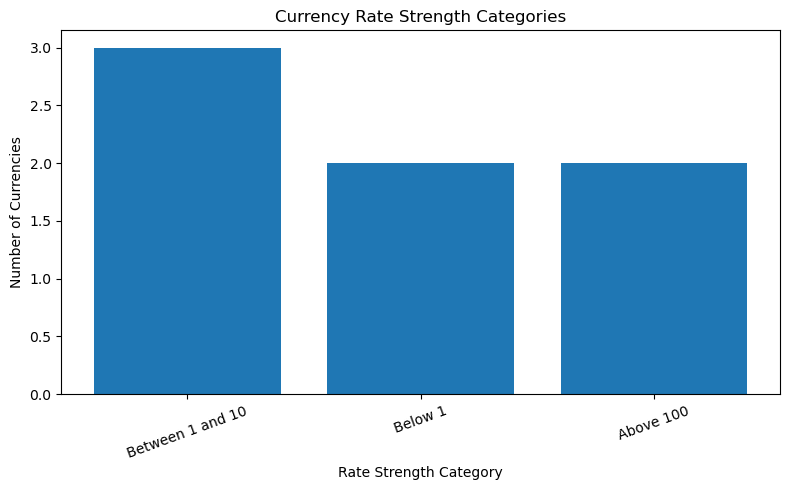

In [20]:
category_counts = (
    currency_df["rate_strength_category"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Currency Rate Strength Categories")
plt.xlabel("Rate Strength Category")
plt.ylabel("Number of Currencies")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
highest_rate = currency_df.loc[
    currency_df["exchange_rate"].idxmax()
]

lowest_rate = currency_df.loc[
    currency_df["exchange_rate"].idxmin()
]

average_rate = currency_df["exchange_rate"].mean()

print("Highest exchange rate:")
print(
    highest_rate["target_currency"],
    highest_rate["exchange_rate"]
)

print("\nLowest exchange rate:")
print(
    lowest_rate["target_currency"],
    lowest_rate["exchange_rate"]
)

print("\nAverage exchange rate:")
print(round(average_rate, 4))

Highest exchange rate:
JPY 184.88

Lowest exchange rate:
GBP 0.86653

Average exchange rate:
42.749
